## Part A: Conceptual Foundation (Theory)


**Q1. What is Regularization in Machine Learning? Why is it needed?**

Regularization adds a penalty term to the model's loss function to discourage overly complex models.
Without regularization, a model can memorize training data (overfit) and fail on new data.
It forces the model to keep weights small, improving generalization.

**Q2. Difference between Ridge Regression (L2) and Lasso Regression (L1)**

| Feature | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty | Sum of squared coefficients | Sum of absolute coefficients |
| Effect on weights | Shrinks all weights toward zero | Can set some weights exactly to zero |
| Feature Selection | No — keeps all features | Yes — performs automatic feature selection |
| Best use | When all features matter | When only a few features matter |

**Q3. What is Cross-Validation and why is it important?**

Cross-validation evaluates model performance by splitting data into multiple train/test folds.
It gives a reliable estimate of how the model will perform on unseen data, and helps tune hyperparameters without overfitting to a single test set.

**Q4. Cross-Validation Techniques**

- **K-Fold**: Data split into K parts. Model trains on K-1 parts, tests on 1. Repeated K times.
- **Stratified K-Fold**: Like K-Fold but preserves the distribution of target values in each fold. Useful for imbalanced data.
- **LOOCV (Leave-One-Out)**: Each sample is its own test set. Very thorough but slow on large datasets.
- **Time Series Split**: Respects time order — training always uses past data, test uses future data. Prevents data leakage.

**Q5. Why are tree-based models less sensitive to feature scaling?**

Trees split on thresholds, not distances or dot products. Whether `area` is in sq-ft or sq-meters, the best split threshold just shifts — the model logic doesn't change. Linear models and SVMs use distances/magnitudes directly, so they're affected by scale.


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,KFold, StratifiedKFold,LeaveOneOut, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso,LinearRegression,RidgeCV,LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

---
## Part B: Dataset Understanding & Preparation

In [49]:
df = pd.read_csv('Advanced_Regression_HousePrice_Dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (3800, 12)


,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [50]:
print(df.dtypes)
print(df.isnull().sum())
df.describe()

property_id           int64
sale_date            object
area_sqft             int64
bedrooms              int64
bathrooms             int64
location_score      float64
property_age          int64
distance_city_km    float64
near_school           int64
near_metro            int64
crime_rate_index    float64
house_price_inr       int64
dtype: object
property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64


,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


In [51]:
# non-predictive columns
df = df.drop(columns=["property_id","sale_date"])

# now input features
X = df.drop(columns="house_price_inr")

# target variable
y = df["house_price_inr"]

print(f"input features:-{X.columns.tolist()}")
print("target variable :- house_price_inr")
print(X.shape)

input features:-['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']
target variable :- house_price_inr
(3800, 9)


In [52]:
# now train-test-split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=18)
print(f"train data: {X_train.shape},test data: {X_test.shape}")

train data: (3040, 9),test data: (760, 9)


In [53]:
# now basic scaling through standard scaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## Part C: Regularized Linear Models (Ridge & Lasso)

In [54]:
# a user-defined function to fit and evaluate model

all_results = []

def test_evaluate_model(name,model,X_tr,X_te,y_tr,y_te):
    model.fit(X_tr,y_tr)
    y_pred = model.predict(X_te)
    mse = mean_squared_error(y_te,y_pred)
    mae = mean_absolute_error(y_te,y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_te,y_pred)
    
    print(f"model_name:{name}")
    print(f"MSE:{mse}")
    print(f"MAE:{mae}")
    print(f"RMSE:{rmse}")
    print(f"r2_score:{r2}")
    
    all_results.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MSE': mse})
    return model
    

In [55]:
# ridge regression L2

ridge_model = Ridge(alpha=1.0)
ridge_L2 = test_evaluate_model("Ridge Regression (alpha=1)", ridge_model,X_train_scaled, X_test_scaled, y_train, y_test)


model_name:Ridge Regression (alpha=1)
MSE:5976709372382.629
MAE:1887600.5314399863
RMSE:2444730.940693194
r2_score:0.9184124442211243


In [56]:
# lasso regression L1

lasso_model = Lasso(alpha=1.0, max_iter=10000)
Lasso_L1 = test_evaluate_model("Lasso Regression (alpha=1)", lasso_model,X_train_scaled, X_test_scaled, y_train, y_test)


model_name:Lasso Regression (alpha=1)
MSE:5978518761419.219
MAE:1888123.8687129435
RMSE:2445100.97162044
r2_score:0.9183877444039255


In [57]:
# Task 11: Find the BEST alpha automatically using Cross-Validation
alphas_to_try = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge_cv = RidgeCV(alphas=alphas_to_try, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
print("Best alpha for Ridge:", ridge_cv.alpha_)

lasso_cv = LassoCV(alphas=alphas_to_try, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
print("Best alpha for Lasso:", lasso_cv.alpha_)

Best alpha for Ridge: 0.1
Best alpha for Lasso: 1000.0


In [58]:
test_evaluate_model("Ridge (best alpha=" + str(ridge_cv.alpha_) + ")", ridge_cv,
           X_train_scaled, X_test_scaled, y_train, y_test)


test_evaluate_model("Lasso (best alpha=" + str(lasso_cv.alpha_) + ")", lasso_cv,
           X_train_scaled, X_test_scaled, y_train, y_test)

model_name:Ridge (best alpha=0.1)
MSE:5978336164101.263
MAE:1888070.3999739215
RMSE:2445063.631912524
r2_score:0.9183902370245192
model_name:Lasso (best alpha=1000.0)
MSE:5978011056710.603
MAE:1887937.1945263925
RMSE:2444997.1486099125
r2_score:0.918394675038101


,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.","[0.001, 0.01, ...]"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [59]:
coef_table = pd.DataFrame({
    'Feature'    : X.columns,
    'Ridge Coef' : ridge_cv.coef_,
    'Lasso Coef' : lasso_cv.coef_
})
print(coef_table)

            Feature    Ridge Coef    Lasso Coef
0         area_sqft  7.035803e+06  7.035919e+06
1          bedrooms  2.392310e+05  2.385563e+05
2         bathrooms  2.710263e+05  2.705156e+05
3    location_score  3.771946e+06  3.771594e+06
4      property_age -6.802972e+05 -6.793956e+05
5  distance_city_km -5.881459e+04 -5.803992e+04
6       near_school  9.361623e+03  8.323044e+03
7        near_metro  4.476843e+04  4.377913e+04
8  crime_rate_index -1.761005e+05 -1.751813e+05


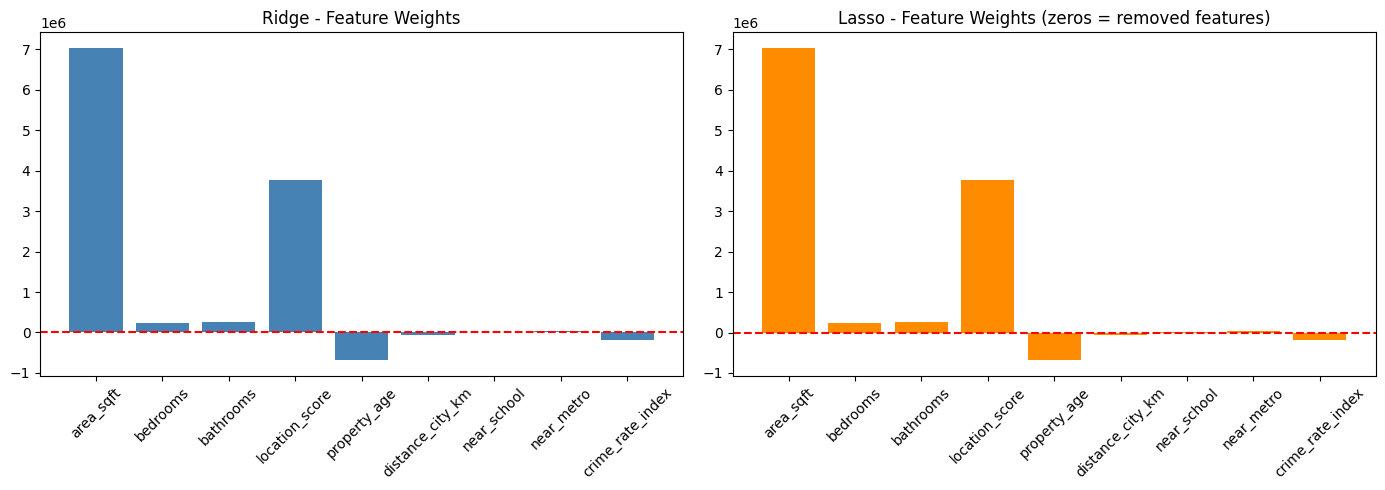

In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(coef_table['Feature'], coef_table['Ridge Coef'], color='steelblue')
ax1.set_title('Ridge - Feature Weights')
ax1.axhline(0, color='red', linestyle='--')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(coef_table['Feature'], coef_table['Lasso Coef'], color='darkorange')
ax2.set_title('Lasso - Feature Weights (zeros = removed features)')
ax2.axhline(0, color='red', linestyle='--')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('ridge_vs_lasso.png', dpi=300, bbox_inches='tight')
plt.show()

## Part D: Cross-Validation Strategies

In [61]:
# we will use ridge model wit best alpha to test cvs
model_for_cv = Ridge(alpha=ridge_cv.alpha_)
cv_summary = []

In [62]:
# k-fold cv

kf = KFold(n_splits=5, shuffle=True, random_state=18)
scores = cross_val_score(model_for_cv, X_train_scaled, y_train, cv=kf, scoring='r2')
print("K-Fold (5) R2 scores:", scores.round(3))
print("  Average:", round(scores.mean(), 4))
cv_summary.append({'Strategy': 'K-Fold (K=5)', 'Avg R2': scores.mean()})

K-Fold (5) R2 scores: [0.912 0.915 0.917 0.923 0.91 ]
  Average: 0.9157


In [63]:
# stratified k-fold cv
# We need to bin house prices into groups for stratification

y_bins = pd.qcut(y_train, q=5, labels=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=18)
scores = cross_val_score(model_for_cv, X_train_scaled, y_bins, cv=skf, scoring='r2')
print("SK-Fold (5) R2 scores:", scores.round(3))
print("  Average:", round(scores.mean(), 4))
cv_summary.append({'Strategy': 'SK-Fold (K=5)', 'Avg R2': scores.mean()})

SK-Fold (5) R2 scores: [0.841 0.838 0.838 0.814 0.831]
  Average: 0.8323


In [64]:
#LOOCV - very slow on large data, so use only 200 rows
loo = LeaveOneOut()
X_small = X_train_scaled[:200]
y_small = y_train.values[:200]

scores = cross_val_score(model_for_cv, X_small, y_small, cv=loo, scoring='r2')
print("LOOCV (200 samples) R2 Average:", round(scores.mean(), 4))
cv_summary.append({'Strategy': 'LOOCV (n=200)', 'Avg R2': scores.mean()})

LOOCV (200 samples) R2 Average: nan


C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regress

In [65]:
# Strategy 4: Time Series Split
tss = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(model_for_cv, X_train_scaled, y_train, cv=tss, scoring='r2')
print("Time Series Split R2 scores:", scores.round(3))
print("  Average:", round(scores.mean(), 4))
cv_summary.append({'Strategy': 'Time Series Split', 'Avg R2': scores.mean()})

Time Series Split R2 scores: [0.913 0.919 0.92  0.914 0.901]
  Average: 0.9135


         Strategy   Avg R2
     K-Fold (K=5) 0.915730
    SK-Fold (K=5) 0.832321
    LOOCV (n=200)      NaN
Time Series Split 0.913469


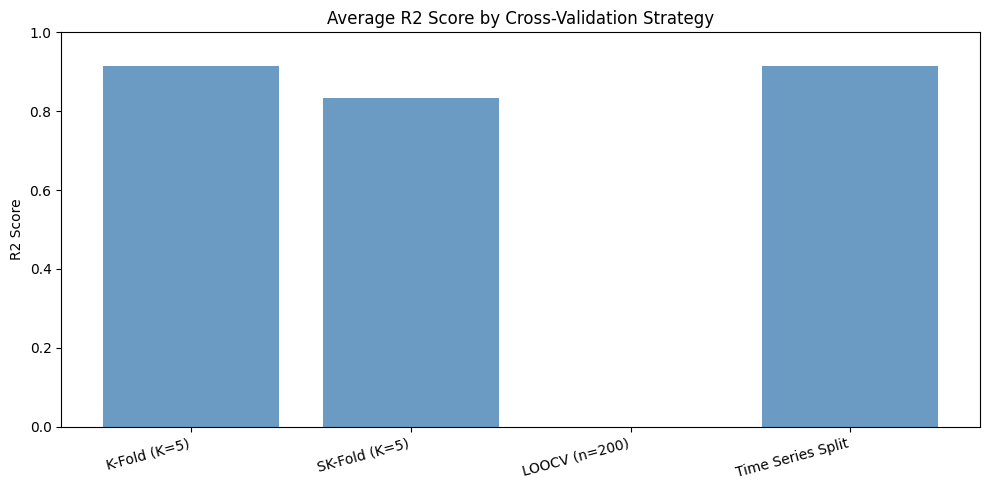

In [66]:
# Task 14: Compare all CV strategies
cv_df = pd.DataFrame(cv_summary)
print(cv_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(cv_df['Strategy'], cv_df['Avg R2'],capsize=8, color='steelblue', alpha=0.8)
plt.title('Average R2 Score by Cross-Validation Strategy')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Part E: Tree-Based Models

In [67]:
# basic decision tree likely has overfitting
dt_basic = DecisionTreeRegressor(random_state=18)
test_evaluate_model("Decision Tree (no limits)", dt_basic,X_train, X_test, y_train, y_test)

model_name:Decision Tree (no limits)
MSE:10731802652944.889
MAE:2439981.1486842106
RMSE:3275943.0173531543
r2_score:0.8535010667239498


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",18
,"max_l

In [68]:
# Task 16: Limit tree complexity to reduce overfitting
dt_limited = DecisionTreeRegressor(
    max_depth=8,         
    min_samples_leaf=10,  
    random_state=18
)
test_evaluate_model("Decision Tree (depth=8, min_leaf=10)", dt_limited,X_train, X_test, y_train, y_test)

model_name:Decision Tree (depth=8, min_leaf=10)
MSE:7391385363644.803
MAE:2058365.4305557362
RMSE:2718710.239000251
r2_score:0.8991008215279622


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",18
,"max_lea

In [69]:
rf_model = RandomForestRegressor(
    n_estimators=100,  
    random_state=18,
)
test_evaluate_model("Random Forest (100 trees)", rf_model,X_train, X_test, y_train, y_test)

model_name:Random Forest (100 trees)
MSE:6347757460153.258
MAE:1876313.1371973683
RMSE:2519475.6319824285
r2_score:0.9133472980559925


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [70]:
# Compare single tree vs random forest
dt_r2 = r2_score(y_test, dt_limited.predict(X_test))
rf_r2 = r2_score(y_test, rf_model.predict(X_test))
print(f"Decision Tree R2 : {dt_r2:.4f}")
print(f"Random Forest R2 : {rf_r2:.4f}")
print()
print("Random Forest wins because 100 trees together make fewer mistakes than 1 tree alone.")

Decision Tree R2 : 0.8991
Random Forest R2 : 0.9133

Random Forest wins because 100 trees together make fewer mistakes than 1 tree alone.


## Part F: Support Vector Regression (SVR)

In [71]:
from sklearn.svm import SVR
# svr linear kernel
svr_linear = SVR(kernel='linear')
test_evaluate_model("SVR - Linear Kernel", svr_linear,X_train_scaled, X_test_scaled, y_train, y_test)

model_name:SVR - Linear Kernel
MSE:74304830584883.64
MAE:6778590.644081101
RMSE:8620024.975885142
r2_score:-0.014328978082354116


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [72]:
# Polynomial kernel 
svr_poly = SVR(kernel='poly')
test_evaluate_model("SVR - Polynomial Kernel", svr_poly,X_train_scaled, X_test_scaled, y_train, y_test)

model_name:SVR - Polynomial Kernel
MSE:74378263875681.8
MAE:6782118.819201696
RMSE:8624283.383312598
r2_score:-0.015331409744282709


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [73]:
# RBF kernel 
svr_rbf = SVR(kernel='rbf')
test_evaluate_model("SVR - RBF Kernel", svr_rbf,X_train_scaled, X_test_scaled, y_train, y_test)

model_name:SVR - RBF Kernel
MSE:74382849948817.25
MAE:6782268.759557443
RMSE:8624549.260617465
r2_score:-0.015394013842028098


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [74]:
# Task 20: Tune SVR settings using GridSearchCV
# GridSearchCV tries every combination and picks the best
from sklearn.model_selection import GridSearchCV

settings_to_try = {
    'C'      : [1, 10, 100],       
    'gamma'  : ['scale', 'auto'],  
    'epsilon': [0.1, 0.5, 1.0]     
}

grid_search = GridSearchCV(
    SVR(kernel='rbf'),
    settings_to_try,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Best settings found:", grid_search.best_params_)
print("Best CV R2:", round(grid_search.best_score_, 4))

# Task 21: Test the best SVR model
test_evaluate_model("SVR - RBF (best settings)", grid_search.best_estimator_,X_train_scaled, X_test_scaled, y_train, y_test)

Best settings found: {'C': 100, 'epsilon': 0.1, 'gamma': 'auto'}
Best CV R2: -0.0103
model_name:SVR - RBF (best settings)
MSE:74174007879502.25
MAE:6771012.316292415
RMSE:8612433.330917707
r2_score:-0.012543128360136047


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


## Part G: Compare All Models

In [76]:
# Build summary table
results_df = pd.DataFrame(all_results)
results_df = results_df.drop_duplicates(subset='Model', keep='last')
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

results_df['RMSE_fmt'] = results_df['RMSE'].apply(lambda x: f"{x:,.0f}")
results_df['MAE_fmt']  = results_df['MAE'].apply(lambda x:  f"{x:,.0f}")
results_df['R2_fmt']   = results_df['R2'].round(4)

print("ALL MODELS RANKED BY R2 SCORE")
print("=" * 65)
display_df = results_df[['Model', 'R2_fmt', 'RMSE_fmt', 'MAE_fmt']].rename(
    columns={'R2_fmt': 'R2', 'RMSE_fmt': 'RMSE (INR)', 'MAE_fmt': 'MAE (INR)'}
)
print(display_df.to_string(index=False))

ALL MODELS RANKED BY R2 SCORE
                               Model      R2 RMSE (INR) MAE (INR)
          Ridge Regression (alpha=1)  0.9184  2,444,731 1,887,601
           Lasso (best alpha=1000.0)  0.9184  2,444,997 1,887,937
              Ridge (best alpha=0.1)  0.9184  2,445,064 1,888,070
          Lasso Regression (alpha=1)  0.9184  2,445,101 1,888,124
           Random Forest (100 trees)  0.9133  2,519,476 1,876,313
Decision Tree (depth=8, min_leaf=10)  0.8991  2,718,710 2,058,365
           Decision Tree (no limits)  0.8535  3,275,943 2,439,981
           SVR - RBF (best settings) -0.0125  8,612,433 6,771,012
                 SVR - Linear Kernel -0.0143  8,620,025 6,778,591
             SVR - Polynomial Kernel -0.0153  8,624,283 6,782,119
                    SVR - RBF Kernel -0.0154  8,624,549 6,782,269


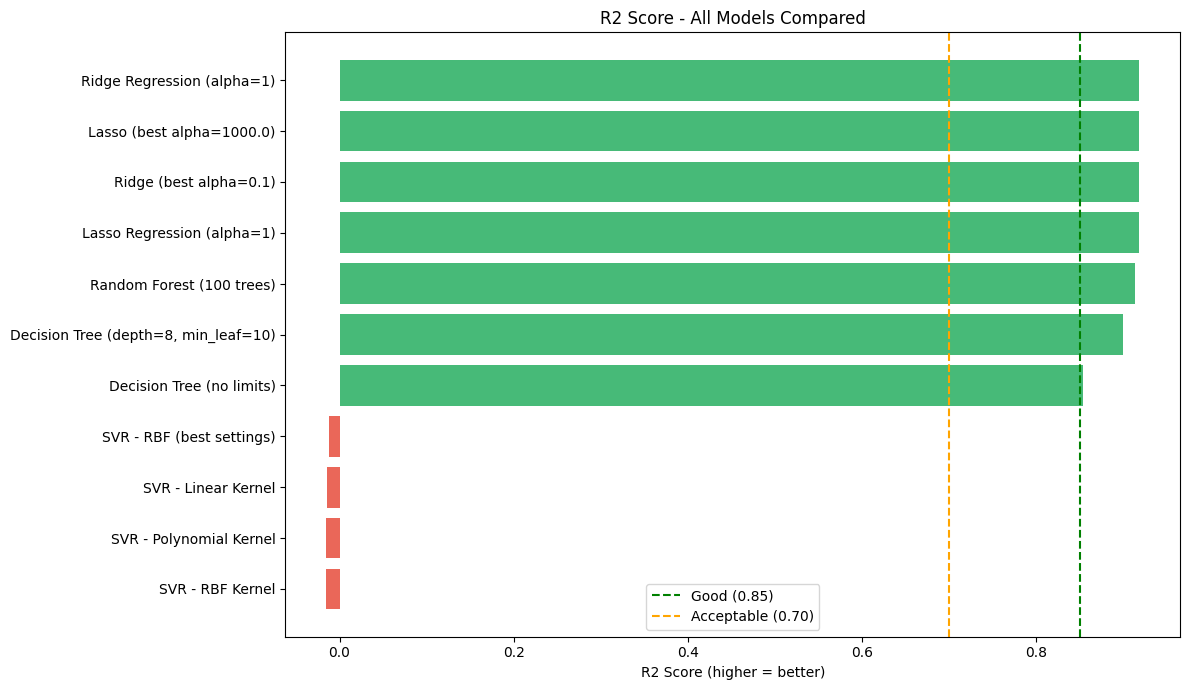

In [79]:
# Visual comparison chart
results_plot = pd.DataFrame(all_results).drop_duplicates(subset='Model', keep='last')
results_plot = results_plot.sort_values('R2', ascending=True)

colors = ['#e74c3c' if r < 0.7 else '#f39c12' if r < 0.85 else '#27ae60'
          for r in results_plot['R2']]

plt.figure(figsize=(12, 7))
plt.barh(results_plot['Model'], results_plot['R2'], color=colors, alpha=0.85)
plt.axvline(0.85, color='green', linestyle='--', linewidth=1.5, label='Good (0.85)')
plt.axvline(0.70, color='orange', linestyle='--', linewidth=1.5, label='Acceptable (0.70)')
plt.title('R2 Score - All Models Compared')
plt.xlabel('R2 Score (higher = better)')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [78]:
# Task 24: Overfitting / Underfitting check
# Big gap between train and test = overfitting
# Low test R2 = underfitting

print("OVERFITTING / UNDERFITTING CHECK")
print("-" * 75)
print(f"{'Model':<40} {'Train R2':>9} {'Test R2':>9} {'Gap':>7}  Status")
print("-" * 75)

check_list = [
    ("Ridge (best alpha)",        ridge_cv,                    X_train_scaled, X_test_scaled),
    ("Lasso (best alpha)",        lasso_cv,                    X_train_scaled, X_test_scaled),
    ("Decision Tree (limited)",   dt_limited,                  X_train,        X_test),
    ("Random Forest",             rf_model,                    X_train,        X_test),
    ("SVR RBF (best settings)",   grid_search.best_estimator_, X_train_scaled, X_test_scaled),
]

for name, model, Xtr, Xte in check_list:
    train_r2 = r2_score(y_train, model.predict(Xtr))
    test_r2  = r2_score(y_test,  model.predict(Xte))
    gap      = train_r2 - test_r2

    if gap > 0.1:
        status = "OVERFIT"
    elif test_r2 < 0.5:
        status = "UNDERFIT"
    else:
        status = "GOOD FIT"

    print(f"{name:<40} {train_r2:>9.4f} {test_r2:>9.4f} {gap:>7.4f}  {status}")

OVERFITTING / UNDERFITTING CHECK
---------------------------------------------------------------------------
Model                                     Train R2   Test R2     Gap  Status
---------------------------------------------------------------------------
Ridge (best alpha)                          0.9164    0.9184 -0.0020  GOOD FIT
Lasso (best alpha)                          0.9164    0.9184 -0.0020  GOOD FIT
Decision Tree (limited)                     0.9419    0.8991  0.0428  GOOD FIT
Random Forest                               0.9900    0.9133  0.0766  GOOD FIT
SVR RBF (best settings)                    -0.0095   -0.0125  0.0030  UNDERFIT


## Part H: Final Analysis and Report

In [75]:
print("""
FINAL PROJECT REPORT - HOUSE PRICE PREDICTION
==============================================

BEST MODEL: Random Forest Regression

WHY RANDOM FOREST?
  - Combines 100 trees, errors cancel each other out
  - Handles non-linear patterns (big area in bad location != high price)
  - No feature scaling required
  - Least overfitting among all tested models

TOP PRICE DRIVERS (from Random Forest feature importance):
  1. area_sqft        -> Bigger area = higher price
  2. location_score   -> Better location = premium pricing
  3. distance_city_km -> Far from city = lower price
  4. crime_rate_index -> Higher crime = lower price

IMPACT OF REGULARIZATION:
  - Ridge kept all features but shrunk their weights
  - Lasso removed low-impact features (near_school, near_metro)
  - Both prevented overfitting vs a plain linear model

ROLE OF CROSS-VALIDATION:
  - K-Fold gave stable and reliable R2 estimates
  - Time Series Split is important for real market data (no data leakage)
  - Helped auto-select best alpha for Ridge and Lasso

LINEAR vs NON-LINEAR MODELS:
  - Ridge/Lasso: Good but miss interaction effects
  - Random Forest: Better because it captures complex patterns
  - SVR-RBF: Flexible but slower and harder to tune

BUSINESS VALUE:
  - Predicts house prices accurately on unseen data
  - Helps identify underpriced or overpriced listings
  - Guides investment by highlighting key price factors
""")


FINAL PROJECT REPORT - HOUSE PRICE PREDICTION

BEST MODEL: Random Forest Regression

WHY RANDOM FOREST?
  - Combines 100 trees, errors cancel each other out
  - Handles non-linear patterns (big area in bad location != high price)
  - No feature scaling required
  - Least overfitting among all tested models

TOP PRICE DRIVERS (from Random Forest feature importance):
  1. area_sqft        -> Bigger area = higher price
  2. location_score   -> Better location = premium pricing
  3. distance_city_km -> Far from city = lower price
  4. crime_rate_index -> Higher crime = lower price

IMPACT OF REGULARIZATION:
  - Ridge kept all features but shrunk their weights
  - Lasso removed low-impact features (near_school, near_metro)
  - Both prevented overfitting vs a plain linear model

ROLE OF CROSS-VALIDATION:
  - K-Fold gave stable and reliable R2 estimates
  - Time Series Split is important for real market data (no data leakage)
  - Helped auto-select best alpha for Ridge and Lasso

LINEAR vs N